In [334]:
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings 
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [335]:
df=pd.read_csv('Churn_Modelling.csv')

In [336]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [338]:
df.duplicated().sum()

0

In [339]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [340]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [341]:
for col in df.columns:
    print(col.ljust(15) ,'*****',len(df[col].unique()))

CreditScore     ***** 460
Geography       ***** 3
Gender          ***** 2
Age             ***** 70
Tenure          ***** 11
Balance         ***** 6382
NumOfProducts   ***** 4
HasCrCard       ***** 2
IsActiveMember  ***** 2
EstimatedSalary ***** 9999
Exited          ***** 2


<Axes: xlabel='CreditScore', ylabel='Count'>

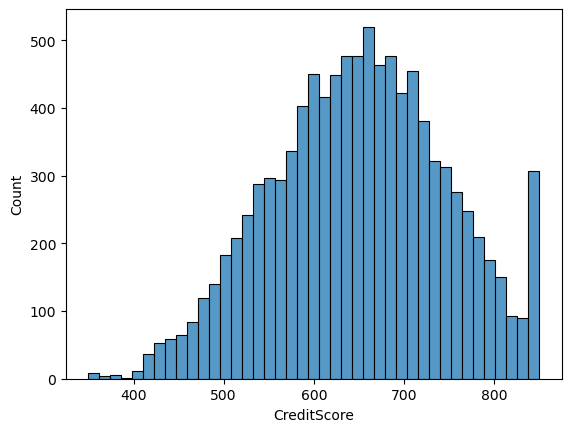

In [342]:
sns.histplot(df['CreditScore'])

<Axes: xlabel='Geography', ylabel='Count'>

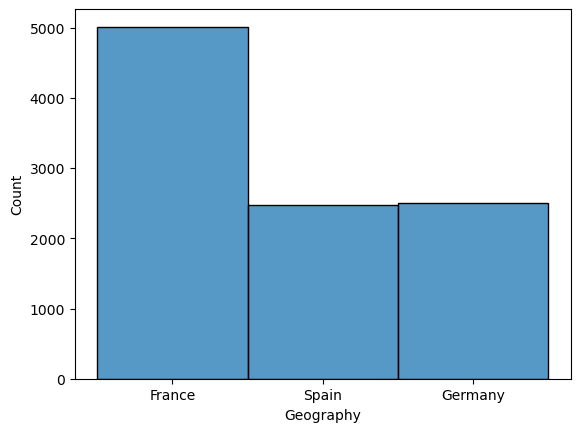

In [343]:
sns.histplot(df['Geography'])

<Axes: xlabel='Gender', ylabel='Count'>

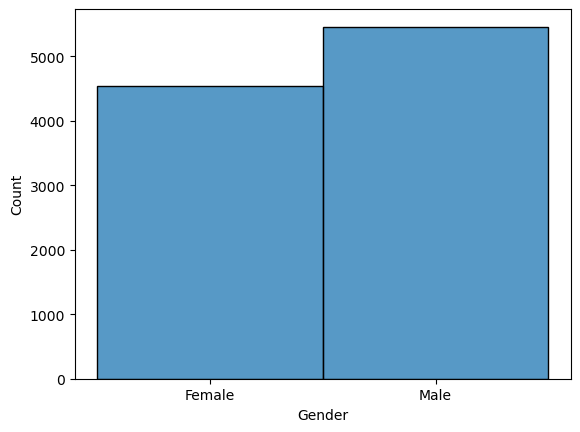

In [344]:
sns.histplot(df['Gender'])

<Axes: xlabel='Age', ylabel='Count'>

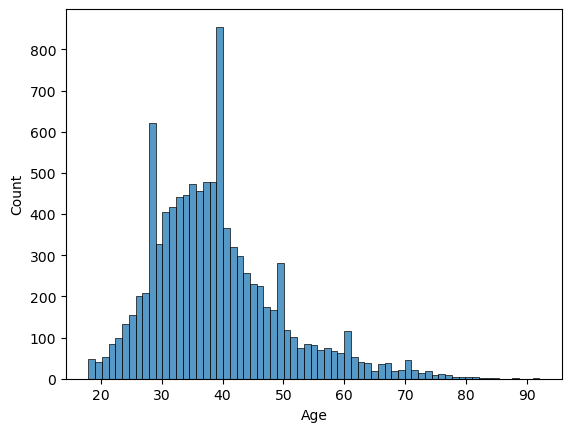

In [345]:
sns.histplot(df['Age'])

In [346]:
df['Age']=np.log(df['Age'])

<Axes: xlabel='Age', ylabel='Count'>

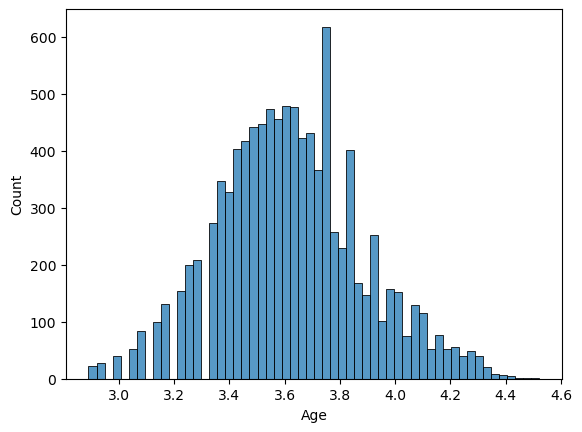

In [347]:
sns.histplot(df['Age'])

<Axes: xlabel='Tenure', ylabel='Count'>

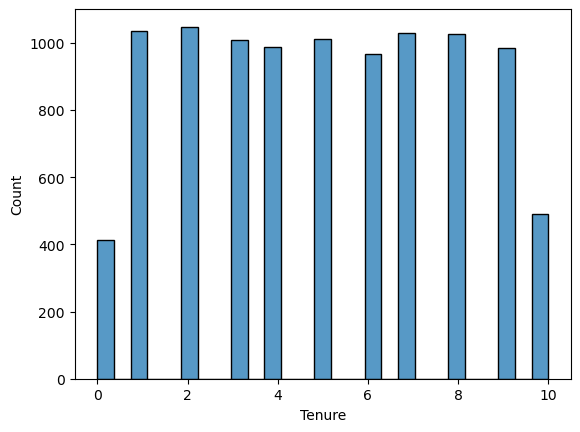

In [348]:
sns.histplot(df['Tenure'])

<Axes: xlabel='Balance', ylabel='Count'>

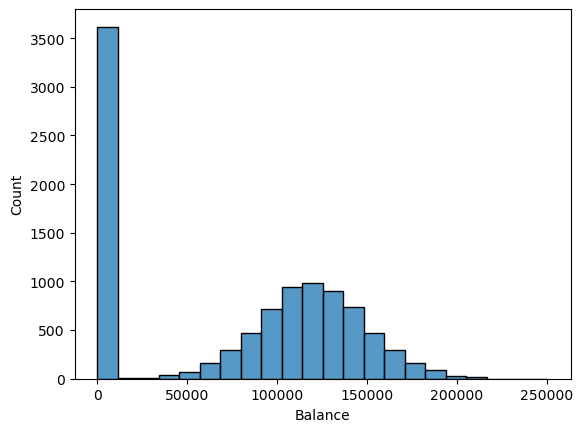

In [349]:
sns.histplot(df['Balance'])

In [350]:
df['Balance'].value_counts()

0.00         3617
130170.82       2
105473.74       2
85304.27        1
159397.75       1
             ... 
81556.89        1
112687.69       1
108698.96       1
238387.56       1
130142.79       1
Name: Balance, Length: 6382, dtype: int64

In [351]:
df[df['Balance']==0]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,3.737670,2,0.0,1,1,1,101348.88,1
3,699,France,Female,3.663562,1,0.0,2,0,0,93826.63,0
6,822,France,Male,3.912023,7,0.0,2,1,1,10062.80,0
11,497,Spain,Male,3.178054,3,0.0,2,1,0,76390.01,0
12,476,France,Female,3.526361,10,0.0,2,1,0,26260.98,0
...,...,...,...,...,...,...,...,...,...,...,...
9989,841,Spain,Male,3.332205,4,0.0,2,1,1,179436.60,0
9992,726,Spain,Male,3.583519,2,0.0,1,1,0,195192.40,0
9994,800,France,Female,3.367296,2,0.0,2,0,0,167773.55,0
9995,771,France,Male,3.663562,5,0.0,2,1,0,96270.64,0


<Axes: xlabel='NumOfProducts', ylabel='Count'>

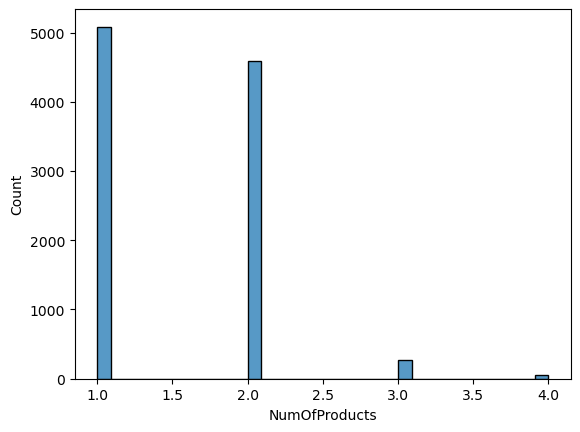

In [352]:
sns.histplot(df['NumOfProducts'])    

<Axes: xlabel='HasCrCard', ylabel='Count'>

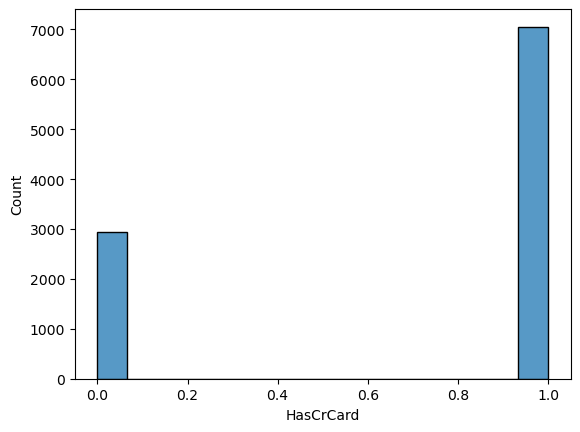

In [353]:
sns.histplot(df['HasCrCard'])    

<Axes: xlabel='IsActiveMember', ylabel='Count'>

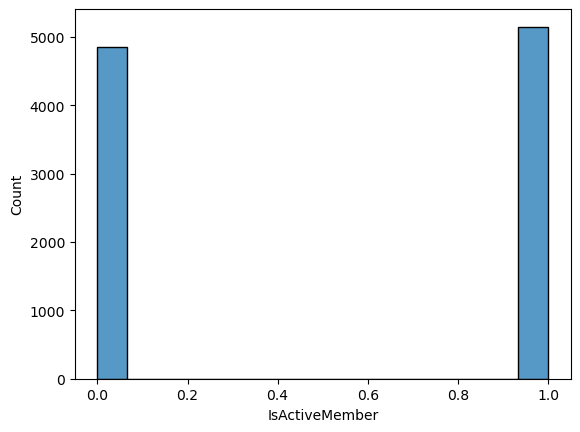

In [354]:
sns.histplot(df['IsActiveMember'])    

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

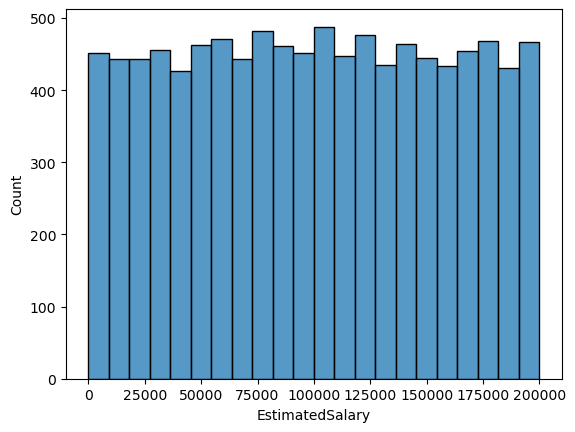

In [355]:
sns.histplot(df['EstimatedSalary'])    

<Axes: xlabel='Exited', ylabel='Count'>

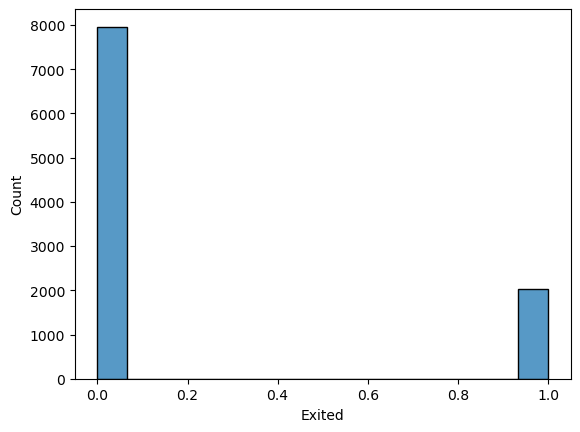

In [356]:
sns.histplot(df['Exited'])    

In [357]:
corr=df.corr()

<Axes: >

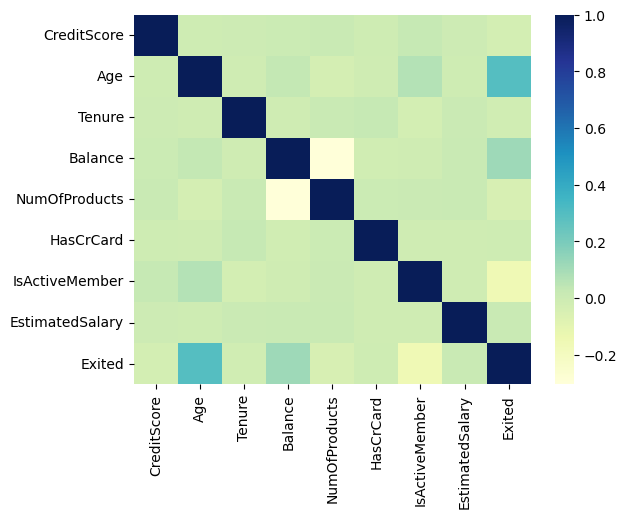

In [391]:
sns.heatmap(corr,cmap='YlGnBu')

#### EDA

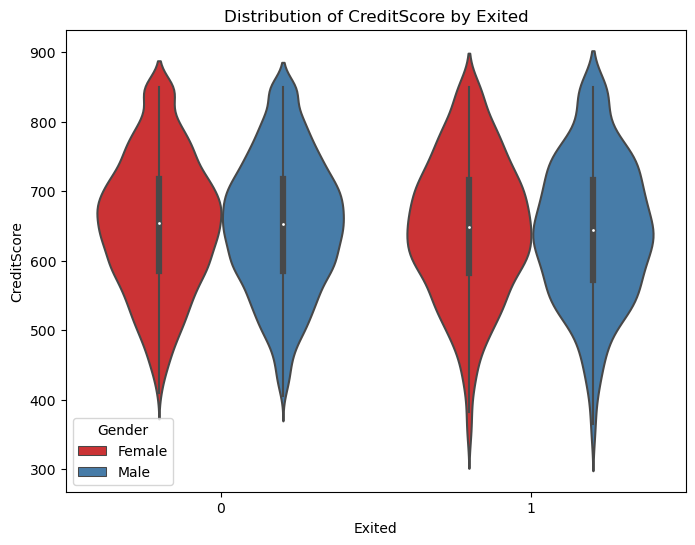

In [24]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Exited', y='CreditScore', palette='Set1',hue='Gender')
plt.title('Distribution of CreditScore by Exited')
plt.xlabel('Exited')
plt.ylabel('CreditScore')
plt.show()

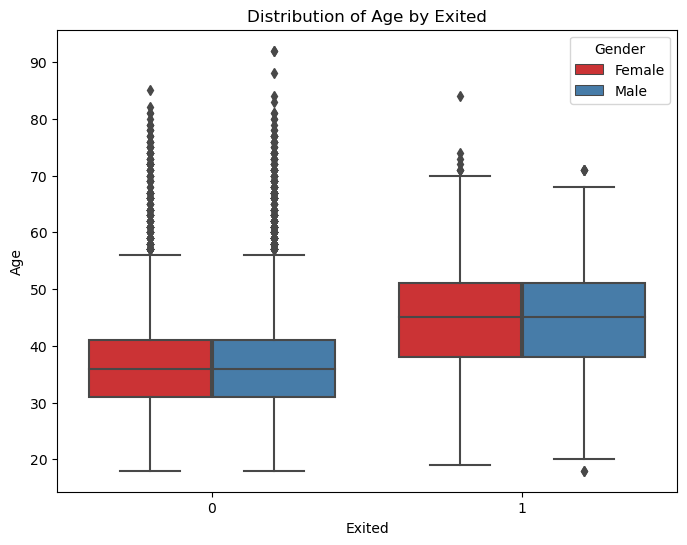

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Exited', y='Age', hue='Gender',palette='Set1')
plt.title('Distribution of Age by Exited')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Exited', y='Tenure', palette='Set1')
plt.title('Distribution of Tenure by Exited')
plt.xlabel('Exited')
plt.ylabel('Tenure')
plt.show()

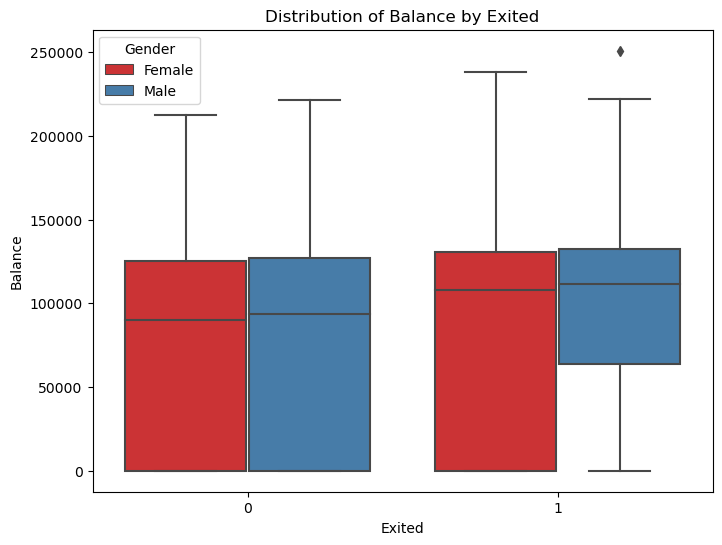

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Exited', y='Balance', palette='Set1',hue='Gender')
plt.title('Distribution of Balance by Exited')
plt.xlabel('Exited')
plt.ylabel('Balance')
plt.show()

<Figure size 800x600 with 0 Axes>

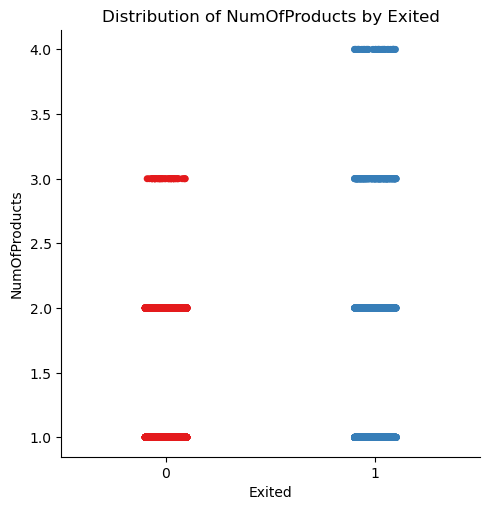

In [28]:
plt.figure(figsize=(8, 6))
sns.catplot(data=df, x='Exited', y='NumOfProducts', palette='Set1')
plt.title('Distribution of NumOfProducts by Exited')
plt.xlabel('Exited')
plt.ylabel('NumOfProducts')
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.catplot(data=df, x='Exited', y='IsActiveMember', palette='Set1')
plt.title('Distribution of IsActiveMember by Exited')
plt.xlabel('Exited')
plt.ylabel('IsActiveMember')
plt.show()

#### handle outliers:

In [359]:
df['Balance'].replace(0,np.nan,inplace=True)

In [360]:
df['Balance'].fillna(df['Balance'].mean(),inplace=True)

In [361]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  float64
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 859.5+ KB


In [362]:
px.histogram(df['Balance'])

In [363]:
balance1=np.log(df['Balance'])

In [364]:
px.histogram(balance1)

## handling outliers

In [365]:
numeric_column = df.select_dtypes(include=[np.number])

In [366]:
numerical_cols = list(numeric_column.columns)


In [367]:
numerical_cols

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [368]:
from datasist.structdata import detect_outliers 

outliears = detect_outliers(df[numerical_cols],0,df[numerical_cols].columns)
df[numerical_cols].drop(outliears,inplace=True)

##### handle credit score

In [369]:
def credit_score_handle(x):
    if 0<=x<580:
        return 'Poor'
    elif 580<=x<670:
        return 'Fair'
    elif 670<=x<740:
        return 'Good'
    elif 740<=x<800:
        return 'Very good'
    elif x>=800:
        return 'Excellent'
df['CreditScore']=df['CreditScore'].apply(credit_score_handle)

In [370]:
df['CreditScore'].value_counts()

Fair         3331
Good         2428
Poor         2362
Very good    1224
Excellent     655
Name: CreditScore, dtype: int64

In [371]:
df['CreditScore']=df['CreditScore'].map({'Poor':0,'Fair':1,'Good':2,'Very good':3,'Excellent':4})

In [372]:
df['CreditScore'].value_counts()

1    3331
2    2428
0    2362
3    1224
4     655
Name: CreditScore, dtype: int64

In [373]:

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,France,Female,3.737670,2,119827.493793,1,1,1,101348.88,1
1,1,Spain,Female,3.713572,1,83807.860000,1,0,1,112542.58,0
2,0,France,Female,3.737670,8,159660.800000,3,1,0,113931.57,1
3,2,France,Female,3.663562,1,119827.493793,2,0,0,93826.63,0
4,4,Spain,Female,3.761200,2,125510.820000,1,1,1,79084.10,0


In [374]:
df['CreditScore'].isnull().sum()

0

In [375]:
df=pd.get_dummies(df,drop_first=True)

In [376]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,3.737670,2,119827.493793,1,1,1,101348.88,1,0,0,0
1,1,3.713572,1,83807.860000,1,0,1,112542.58,0,0,1,0
2,0,3.737670,8,159660.800000,3,1,0,113931.57,1,0,0,0
3,2,3.663562,1,119827.493793,2,0,0,93826.63,0,0,0,0
4,4,3.761200,2,125510.820000,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,3.663562,5,119827.493793,2,1,0,96270.64,0,0,0,1
9996,0,3.555348,10,57369.610000,1,1,1,101699.77,0,0,0,1
9997,2,3.583519,7,119827.493793,1,0,1,42085.58,1,0,0,0
9998,3,3.737670,3,75075.310000,2,1,0,92888.52,1,1,0,1


In [377]:
x=df.drop('Exited',axis=1)
y=df['Exited']

In [378]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [379]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


#### Feature Scaling 


In [380]:
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

#### Modeling

##### logistic regression

In [385]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.neighbors import KNeighborsClassifier

lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [386]:
print('acuuracy x_train',accuracy_score(y_train,lr.predict(x_train)))
print('acuuracy x_test',accuracy_score(y_test,lr.predict(x_test)))
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

acuuracy x_train 0.815125
acuuracy x_test 0.8195
[[1534   61]
 [ 300  105]]
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      1595
           1       0.63      0.26      0.37       405

    accuracy                           0.82      2000
   macro avg       0.73      0.61      0.63      2000
weighted avg       0.80      0.82      0.79      2000



#### svc

In [383]:
from sklearn.svm import SVC

model = SVC()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Training Accuracy :", model.score(x_train, y_train))
print("Testing Accuracy :", model.score(x_test, y_test))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Training Accuracy : 0.869625
Testing Accuracy : 0.863
[[1541   54]
 [ 220  185]]


##### KNN

In [387]:
knn=KNeighborsClassifier()
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print(f'Training Accuracy: {accuracy_score(y_train, knn.predict(x_train))}')
print(f'Testing Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Testing Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Testing Classification report: \n{classification_report(y_test, y_pred)}')

Training Accuracy: 0.873125
Testing Accuracy: 0.831
Testing Confusion Matrix: 
[[1493  102]
 [ 236  169]]
Testing Classification report: 
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1595
           1       0.62      0.42      0.50       405

    accuracy                           0.83      2000
   macro avg       0.74      0.68      0.70      2000
weighted avg       0.81      0.83      0.82      2000

